#### Dataset: S&P 500 constituent stocks via `yfinance` (2015–2024, 10 years)  
#### Method: HMM regime detection → LightGBM return forecasting → Markowitz MVO with regime-conditioned covariance  
#### Benchmark: Equal-weight, S&P 500 (SPY), Sharpe-maximized Markowitz (no ML)

In [10]:
#install libraries
%pip install numpy pandas matplotlib seaborn scikit-learn yfinance cvxpy scipy statsmodels jupyter ipykernel notebook jupyterlab plotly streamlit tqdm lightgbm hmmlearn
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from hmmlearn.hmm import GaussianHMM
import joblib
import json
import os

#style 
plt.style.use('dark_background')
sns.set_palette('viridis')
ACCENT = '#34d399'   # emerald
ACCENT2 = '#f59e0b'  # amber
ACCENT3 = '#60a5fa'  # blue
RED     = '#f87171'  # red

np.random.seed(42)
os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print('All imports successful')
print(f'   LightGBM  v{lgb.__version__}')
print(f'   Pandas    v{pd.__version__}')
print(f'   NumPy     v{np.__version__}')

Note: you may need to restart the kernel to use updated packages.
All imports successful
   LightGBM  v4.6.0
   Pandas    v3.0.1
   NumPy     v2.4.3


1. Data Collection — S&P 500 Constituents (2015–2024)

In [15]:
#universe: diversified cross-sector S&P 500 stocks 
TICKERS = {
    'Tech':       ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META'],
    'Finance':    ['JPM', 'BAC', 'GS', 'MS', 'BLK'],
    'Healthcare': ['JNJ', 'UNH', 'PFE', 'ABBV', 'MRK'],
    'Energy':     ['XOM', 'CVX', 'COP', 'SLB', 'EOG'],
    'Consumer':   ['AMZN', 'WMT', 'HD', 'MCD', 'NKE'],
    'Utilities':  ['NEE', 'DUK', 'SO', 'AEP', 'EXC'],
}

ALL_TICKERS = [t for sector_tickers in TICKERS.values() for t in sector_tickers]
BENCHMARK   = ['SPY']  # S&P 500 ETF

START = '2015-01-01'
END   = '2024-12-31'

print(f'Downloading {len(ALL_TICKERS)} stocks + SPY benchmark ({START} → {END})...')

raw = yf.download(
    ALL_TICKERS + BENCHMARK,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False
)['Close']

#cleaning: drop if >5% missing 
missing_pct = raw.isnull().mean()
keep = missing_pct[missing_pct < 0.05].index.tolist()
raw = raw[keep].ffill().dropna()

spy = raw['SPY'].copy()
prices = raw.drop(columns=['SPY'])

print(f'   Date range: {prices.index[0].date()} → {prices.index[-1].date()}')

#save to csv
prices.to_csv('../data/prices.csv')
spy.to_csv('../data/spy.csv')

prices.tail(3)

   Date range: 2015-01-02 → 2024-12-30


Ticker,AAPL,ABBV,AEP,AMZN,BAC,BLK,COP,CVX,DUK,EOG,...,MSFT,NEE,NKE,NVDA,PFE,SLB,SO,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-26,257.612732,171.763855,88.261894,227.050003,43.296783,1027.382935,92.927162,136.268204,103.646606,115.286171,...,433.911407,69.705528,74.678391,139.884171,24.359846,36.357761,79.532883,495.016174,91.722000,102.039902
2024-12-27,254.201370,170.623245,88.693336,223.750000,43.092686,1017.540710,92.955917,136.287140,103.675323,115.276596,...,426.404083,69.455101,74.173668,136.965118,24.414879,36.425209,79.820908,493.892853,90.605003,102.030327
2024-12-30,250.829788,168.888336,88.261894,221.300003,42.674786,1001.218079,93.118973,135.406952,103.072449,115.448936,...,420.758667,69.117981,72.455696,137.444962,24.231447,36.434853,79.091248,491.771942,89.527542,101.340408


In [12]:
#compute log returns 
returns = np.log(prices / prices.shift(1)).dropna()
spy_ret = np.log(spy / spy.shift(1)).dropna()

print('Return stats (annualized):')
ann_ret  = returns.mean() * 252
ann_vol  = returns.std() * np.sqrt(252)
sharpe   = ann_ret / ann_vol

summary = pd.DataFrame({
    'Ann. Return (%)':  (ann_ret * 100).round(2),
    'Ann. Vol (%)':     (ann_vol * 100).round(2),
    'Sharpe':            sharpe.round(3),
}).sort_values('Sharpe', ascending=False)

print(summary.head(10).to_string())

Return stats (annualized):
        Ann. Return (%)  Ann. Vol (%)  Sharpe
Ticker                                       
NVDA              56.64         48.22   1.175
MSFT              23.65         27.13   0.871
AAPL              23.43         28.47   0.823
AMZN              26.70         32.66   0.817
GOOGL             19.86         28.42   0.699
MCD               13.91         20.40   0.682
UNH               17.73         26.20   0.677
WMT               13.55         21.13   0.641
HD                15.63         24.57   0.636
JPM               16.17         27.32   0.592


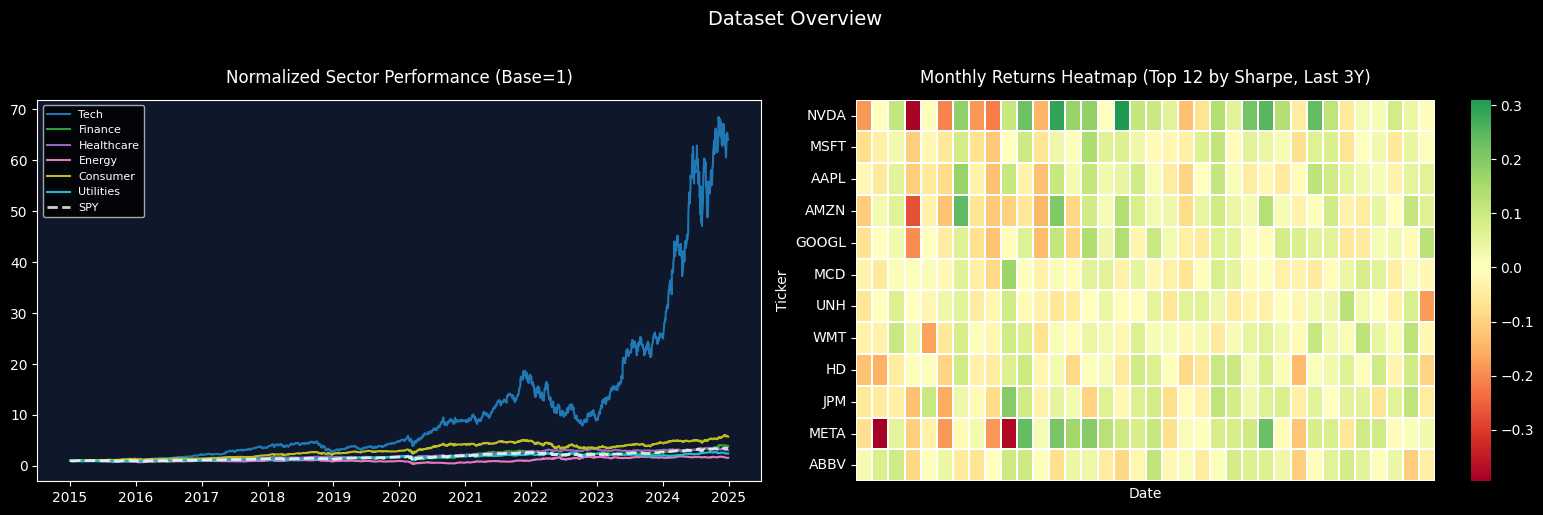

results/01_data_overview.png


In [14]:
#visualization: Normalized price performance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#left sector normalized performance
ax = axes[0]
colors_map = plt.cm.tab10(np.linspace(0, 1, len(TICKERS)))
for (sector, tickers), color in zip(TICKERS.items(), colors_map):
    valid = [t for t in tickers if t in prices.columns]
    sector_idx = (prices[valid] / prices[valid].iloc[0]).mean(axis=1)
    ax.plot(sector_idx.index, sector_idx, label=sector, color=color, linewidth=1.5)

spy_norm = spy / spy.iloc[0]
ax.plot(spy_norm.index, spy_norm, 'w--', linewidth=2, label='SPY', alpha=0.8)
ax.set_title('Normalized Sector Performance (Base=1)', color='white', pad=12)
ax.legend(fontsize=8, loc='upper left')
ax.set_facecolor('#0f172a')

#right distribution heatmap
ax2 = axes[1]
monthly_ret = returns.resample('ME').sum()
top_stocks = sharpe.nlargest(12).index
sns.heatmap(
    monthly_ret[top_stocks].T.iloc[:, -36:],  ax=ax2,cmap='RdYlGn',center=0,xticklabels=False,linewidths=0.3,annot=False,)
ax2.set_title('Monthly Returns Heatmap (Top 12 by Sharpe, Last 3Y)', color='white', pad=12)
ax2.set_facecolor('#0f172a')

plt.suptitle('Dataset Overview', color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/01_data_overview.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print('results/01_data_overview.png')

2. Market Regime Detection — Hidden Markov Model (HMM)

**Why HMM?** Financial markets alternate between latent regimes (bull/bear/sideways). HMM learns these from observable return sequences without requiring labeled data. Regime-conditioned covariance matrices dramatically improve portfolio robustness during crises.

**Reference**: Hamilton (1989), Ang & Timmermann (2012)

In [16]:
#build market features for HMM 
mkt_ret = spy_ret.loc[returns.index]

def build_market_features(mkt_ret):
    df = pd.DataFrame(index=mkt_ret.index)
    df['ret']      = mkt_ret
    df['vol_5d']   = mkt_ret.rolling(5).std()
    df['vol_21d']  = mkt_ret.rolling(21).std()
    df['ret_5d']   = mkt_ret.rolling(5).mean()
    df['ret_21d']  = mkt_ret.rolling(21).mean()
    df['skew_21d'] = mkt_ret.rolling(21).apply(skew, raw=True)
    df['vol_ratio'] = df['vol_5d'] / df['vol_21d']  # vol regime indicator
    return df.dropna()

hmm_features = build_market_features(mkt_ret)
print(f'HMM feature matrix: {hmm_features.shape}')

#fit HMM
N_REGIMES = 3  # Bull / Bear / Sideways/Transition

scaler_hmm = StandardScaler()
X_hmm = scaler_hmm.fit_transform(hmm_features.values)

hmm = GaussianHMM(
    n_components=N_REGIMES,covariance_type='full',n_iter=200,random_state=42,verbose=False)
hmm.fit(X_hmm)

regimes = hmm.predict(X_hmm)
regime_probs = hmm.predict_proba(X_hmm)

print(f'Log-likelihood: {hmm.score(X_hmm):.4f}')
print(f'\nRegime distribution:')
for i in range(N_REGIMES):
    pct = (regimes == i).mean() * 100
    avg_ret = hmm_features.iloc[regimes == i]['ret'].mean() * 252 * 100
    avg_vol = hmm_features.iloc[regimes == i]['vol_21d'].mean() * np.sqrt(252) * 100
    print(f'  Regime {i}: {pct:.1f}% of days | Ann.Ret={avg_ret:.1f}% | Ann.Vol={avg_vol:.1f}%')

HMM feature matrix: (2494, 7)
Log-likelihood: -13074.0090

Regime distribution:
  Regime 0: 48.1% of days | Ann.Ret=17.5% | Ann.Vol=8.7%
  Regime 1: 34.4% of days | Ann.Ret=25.7% | Ann.Vol=16.7%
  Regime 2: 17.5% of days | Ann.Ret=-26.7% | Ann.Vol=27.8%


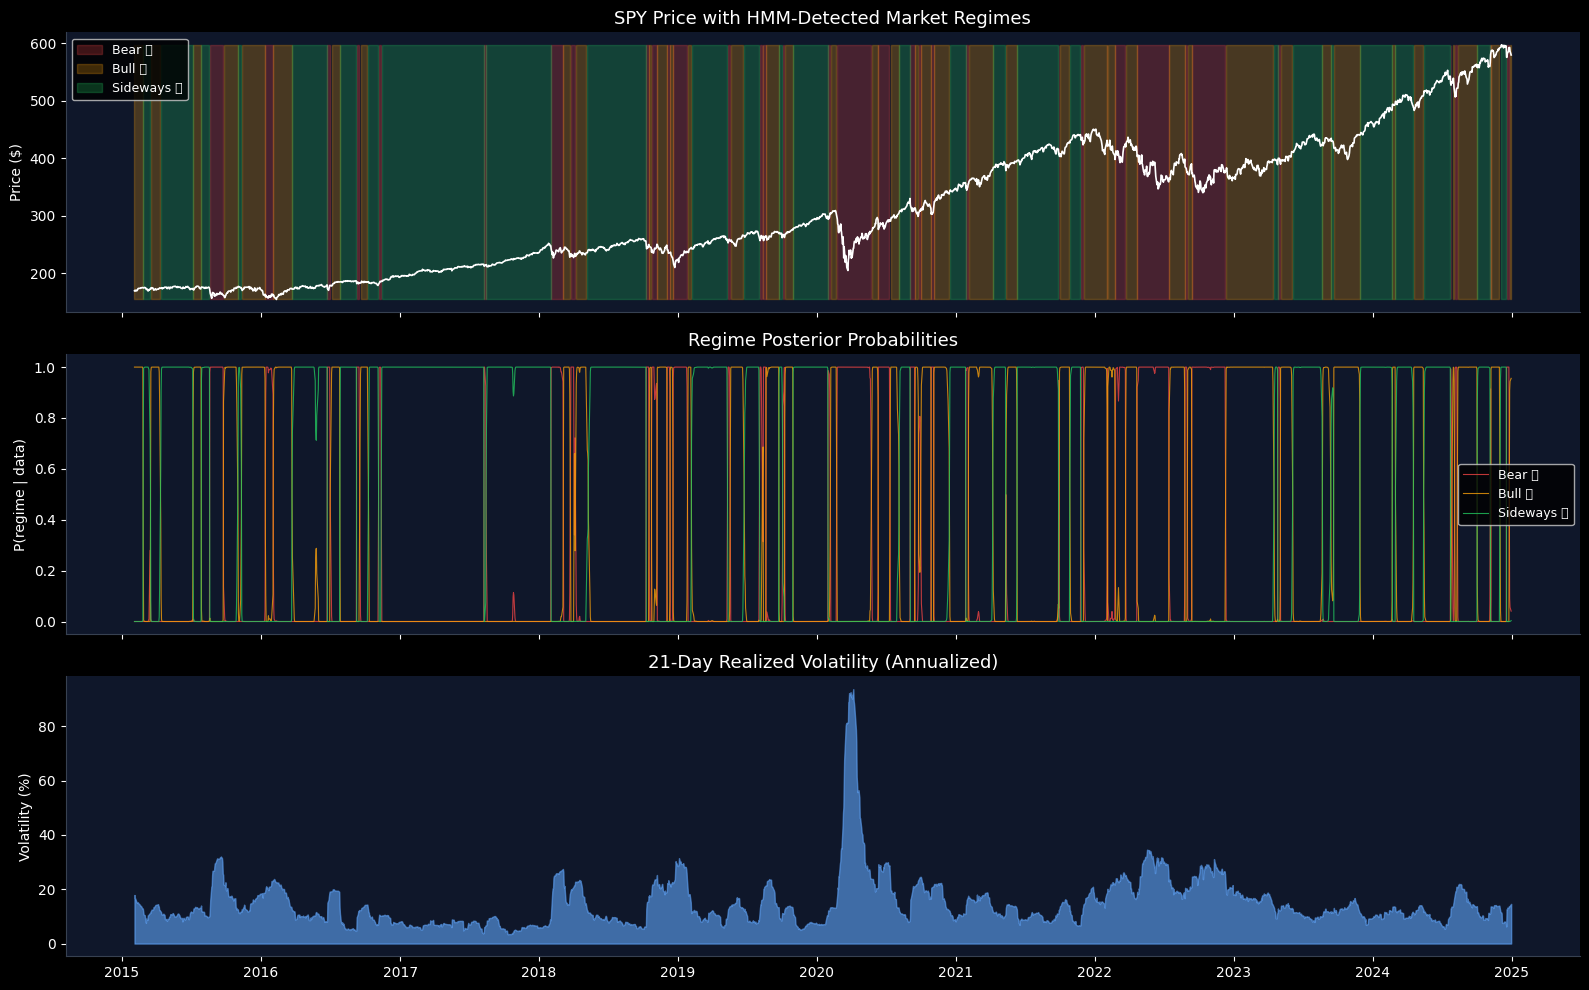

In [17]:
#label regimes by mean return
regime_returns = []
for i in range(N_REGIMES):
    avg = hmm_features.iloc[regimes == i]['ret'].mean()
    regime_returns.append((i, avg))

regime_returns.sort(key=lambda x: x[1])
REGIME_LABELS = {}
label_names   = ['Bear 🔴', 'Sideways 🟡', 'Bull 🟢']
for label, (regime_id, _) in zip(label_names, regime_returns):
    REGIME_LABELS[regime_id] = label

regime_series = pd.Series(regimes, index=hmm_features.index)
regime_named  = regime_series.map(REGIME_LABELS)

#plot: Regimes over time
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

#panel 1: SPY price with regime background
ax = axes[0]
spy_aligned = spy.loc[hmm_features.index]
ax.plot(spy_aligned.index, spy_aligned, color='white', linewidth=1.2, zorder=3)

regime_colors = {0: '#ef4444', 1: '#f59e0b', 2: '#22c55e'}
sorted_regimes = sorted(REGIME_LABELS.keys(), key=lambda k: REGIME_LABELS[k])

for regime_id in sorted_regimes:
    mask = regime_series == regime_id
    color = regime_colors[sorted_regimes.index(regime_id)]
    ax.fill_between(
        spy_aligned.index,spy_aligned.min(), spy_aligned.max(),where=mask.values,alpha=0.25, color=color, label=REGIME_LABELS[regime_id])

ax.set_title('SPY Price with HMM-Detected Market Regimes', color='white', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.set_facecolor('#0f172a')
ax.set_ylabel('Price ($)', color='white')

#panel 2: Regime probability over time
ax2 = axes[1]
cols = ['#ef4444', '#f59e0b', '#22c55e']
for i, (regime_id, col) in enumerate(zip(sorted_regimes, cols)):
    ax2.plot(
        hmm_features.index,regime_probs[:, regime_id],color=col, alpha=0.8, linewidth=0.8,label=REGIME_LABELS[regime_id])
ax2.set_title('Regime Posterior Probabilities', color='white', fontsize=13)
ax2.set_ylabel('P(regime | data)', color='white')
ax2.set_facecolor('#0f172a')
ax2.legend(fontsize=9)

# Panel 3: 21-day realized volatility
ax3 = axes[2]
vol21 = hmm_features['vol_21d'] * np.sqrt(252) * 100
ax3.fill_between(vol21.index, vol21, alpha=0.6, color=ACCENT3)
ax3.set_title('21-Day Realized Volatility (Annualized)', color='white', fontsize=13)
ax3.set_ylabel('Volatility (%)', color='white')
ax3.set_facecolor('#0f172a')

for ax in axes:
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#374151')
    ax.spines['left'].set_color('#374151')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/02_market_regimes.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

3. Feature Engineering for Return Prediction

In [18]:
def build_features(prices, returns, spy_ret, regime_series):
    """
    Build per-stock feature matrix for LightGBM return forecasting.
    Features: momentum, mean-reversion, volatility, regime, cross-sectional rank.
    """
    feat_frames = []
    
    for ticker in returns.columns:
        r = returns[ticker]
        p = prices[ticker]
        
        df = pd.DataFrame(index=r.index)
        
        #momentum features 
        df['ret_1d']   = r.shift(1)
        df['ret_5d']   = r.shift(1).rolling(5).sum()
        df['ret_21d']  = r.shift(1).rolling(21).sum()
        df['ret_63d']  = r.shift(1).rolling(63).sum()
        df['ret_252d'] = r.shift(1).rolling(252).sum()
        
        #mean-reversion
        df['rsi_14'] = (
            r.shift(1).rolling(14).apply(
                lambda x: 100 - 100 / (1 + x[x > 0].mean() / (-x[x < 0].mean() + 1e-8)),
                raw=True
            )
        )
        ma50 = p.shift(1).rolling(50).mean()
        df['dist_ma50'] = (p.shift(1) - ma50) / ma50
        
        #volatility features 
        df['vol_5d']    = r.shift(1).rolling(5).std()
        df['vol_21d']   = r.shift(1).rolling(21).std()
        df['vol_ratio'] = df['vol_5d'] / df['vol_21d']
        df['skew_21d']  = r.shift(1).rolling(21).apply(skew, raw=True)
        
        #market beta (rolling 63d) 
        spy_aligned = spy_ret.reindex(r.index).fillna(0)
        cov_roll = r.shift(1).rolling(63).cov(spy_aligned.shift(1))
        var_roll = spy_aligned.shift(1).rolling(63).var()
        df['beta_63d'] = cov_roll / (var_roll + 1e-10)
        
        #regime dummies
        reg_aligned = regime_series.reindex(r.index).ffill()
        bull_id = [k for k, v in REGIME_LABELS.items() if 'Bull' in v][0]
        bear_id = [k for k, v in REGIME_LABELS.items() if 'Bear' in v][0]
        df['regime_bull'] = (reg_aligned == bull_id).astype(float)
        df['regime_bear'] = (reg_aligned == bear_id).astype(float)
        
        #target: next-day log return
        df['target'] = r  # shifted in training loop
        
        df['ticker'] = ticker
        feat_frames.append(df)
    
    all_features = pd.concat(feat_frames).dropna()
    return all_features

features_df = build_features(prices, returns, spy_ret, regime_series)
print(f'Feature matrix: {features_df.shape}')
print(f'   Features: {[c for c in features_df.columns if c not in ["target", "ticker"]]}')  

Feature matrix: (67856, 16)
   Features: ['ret_1d', 'ret_5d', 'ret_21d', 'ret_63d', 'ret_252d', 'rsi_14', 'dist_ma50', 'vol_5d', 'vol_21d', 'vol_ratio', 'skew_21d', 'beta_63d', 'regime_bull', 'regime_bear']


4. LightGBM Return Forecasting — Walk-Forward Validation

**Why LightGBM over neural nets?** For tabular financial data with ~50k rows, gradient boosted trees outperform deep learning while being interpretable via SHAP. The walk-forward design prevents look-ahead bias — essential for finance.

In [19]:
FEATURE_COLS = [
    'ret_1d', 'ret_5d', 'ret_21d', 'ret_63d', 'ret_252d','rsi_14', 'dist_ma50','vol_5d', 'vol_21d', 'vol_ratio', 'skew_21d','beta_63d', 'regime_bull', 'regime_bear']

#walk-Forward: Train 3Y → Predict 1Y → Slide
#5 folds covering 2018–2024
TRAIN_YEARS = 3
TEST_YEARS  = 1

dates = features_df.index.unique().sort_values()
fold_results = []
all_predictions = []

lgb_params = {
    'objective':'regression','metric':'rmse','learning_rate':0.03,'num_leaves':63,'min_child_samples':50,'feature_fraction': 0.8,'bagging_fraction': 0.8,'bagging_freq':5,'lambda_l1':0.1,'lambda_l2':0.1,'verbose':-1,'n_jobs':-1,}

fold_starts = pd.date_range(start='2018-01-01', periods=5, freq='YS')

print('Running Walk-Forward Validation...')
print('=' * 60)

best_model = None
best_fold_ic = -np.inf

for fold_i, fold_start in enumerate(fold_starts):
    train_start = fold_start - pd.DateOffset(years=TRAIN_YEARS)
    train_end   = fold_start - pd.Timedelta(days=1)
    test_start  = fold_start
    test_end    = fold_start + pd.DateOffset(years=TEST_YEARS) - pd.Timedelta(days=1)
    
    # Filter available dates
    train_mask = (features_df.index >= train_start) & (features_df.index <= train_end)
    test_mask  = (features_df.index >= test_start)  & (features_df.index <= test_end)
    
    if train_mask.sum() < 100 or test_mask.sum() < 10:
        continue
    
    X_train = features_df.loc[train_mask, FEATURE_COLS]
    y_train = features_df.loc[train_mask, 'target']
    X_test  = features_df.loc[test_mask,  FEATURE_COLS]
    y_test  = features_df.loc[test_mask,  'target']
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    
    dtrain = lgb.Dataset(X_train_s, label=y_train, feature_name=FEATURE_COLS)
    dval   = lgb.Dataset(X_test_s,  label=y_test,  reference=dtrain)
    
    callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    model = lgb.train(
        lgb_params,dtrain,num_boost_round=500,valid_sets=[dval],callbacks=callbacks)
    
    preds = model.predict(X_test_s)
    
    # Information Coefficient (rank correlation = key metric in quant finance)
    ic = pd.Series(preds).corr(pd.Series(y_test.values), method='spearman')
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    fold_results.append({'fold': fold_i+1, 'train_start': train_start.date(),
                         'test_start': test_start.date(), 'IC': ic, 'RMSE': rmse,
                         'n_train': len(y_train), 'n_test': len(y_test)})
    
    if ic > best_fold_ic:
        best_fold_ic = ic
        best_model   = model
        best_scaler  = scaler
    
    # Store predictions
    pred_df = features_df.loc[test_mask, ['ticker']].copy()
    pred_df['pred_ret'] = preds
    pred_df['actual_ret'] = y_test.values
    all_predictions.append(pred_df)
    
    print(f'  Fold {fold_i+1} | Test: {test_start.date()} → {test_end.date()} | IC={ic:.4f} | RMSE={rmse:.6f}')

fold_df = pd.DataFrame(fold_results)
all_preds_df = pd.concat(all_predictions)

print('\n' + '=' * 60)
print(f'Mean IC:   {fold_df["IC"].mean():.4f} ± {fold_df["IC"].std():.4f}')
print(f'Mean RMSE: {fold_df["RMSE"].mean():.6f}')

Running Walk-Forward Validation...
  Fold 1 | Test: 2018-01-01 → 2018-12-31 | IC=0.0123 | RMSE=0.016890
  Fold 2 | Test: 2019-01-01 → 2019-12-31 | IC=0.0063 | RMSE=0.014246
  Fold 3 | Test: 2020-01-01 → 2020-12-31 | IC=0.0798 | RMSE=0.031025
  Fold 4 | Test: 2021-01-01 → 2021-12-31 | IC=0.0201 | RMSE=0.016205
  Fold 5 | Test: 2022-01-01 → 2022-12-31 | IC=0.0214 | RMSE=0.022590

Mean IC:   0.0280 ± 0.0296
Mean RMSE: 0.020191


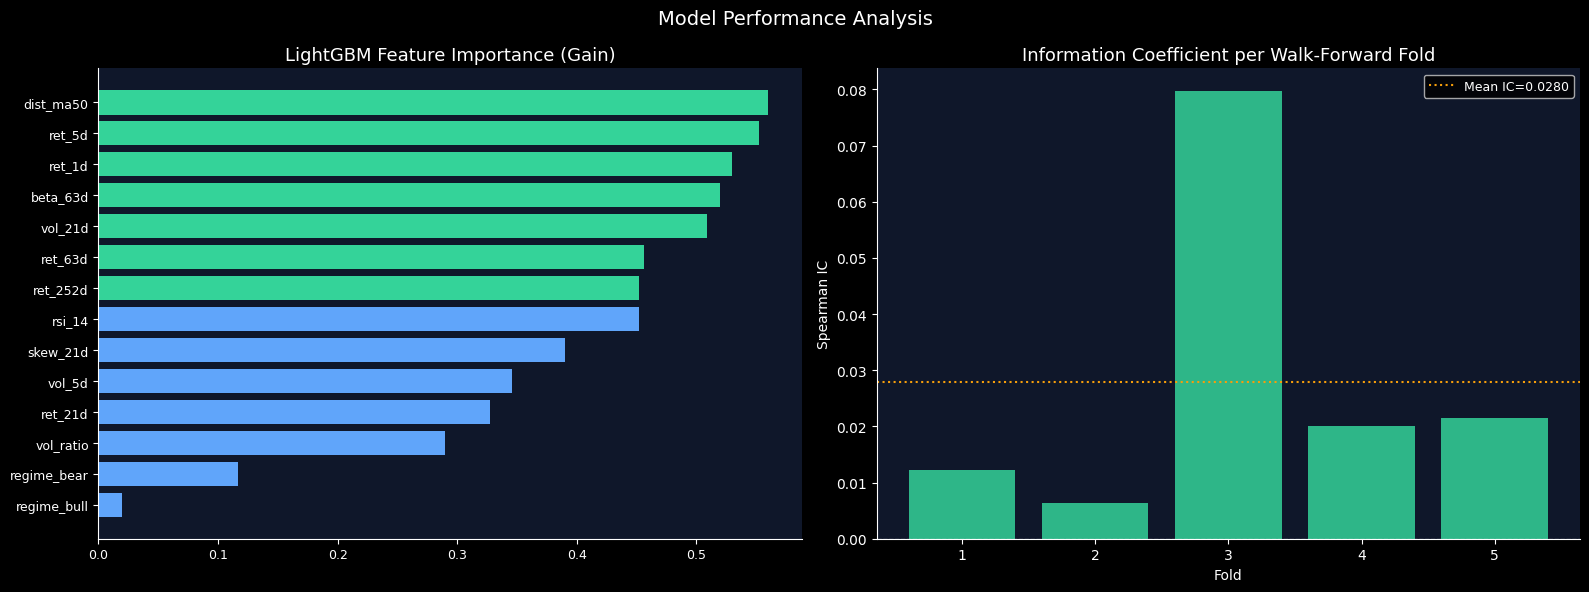

In [20]:
#feature Importance (SHAP-style from LightGBM)
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': best_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#feature importance
ax = axes[0]
colors = [ACCENT if x > importance['importance'].median() else ACCENT3 
          for x in importance['importance']]
bars = ax.barh(importance['feature'], importance['importance'], color=colors)
ax.set_title('LightGBM Feature Importance (Gain)', color='white', fontsize=13)
ax.set_facecolor('#0f172a')
ax.tick_params(colors='white', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#walk-forward IC per fold
ax2 = axes[1]
bar_colors = [ACCENT if ic > 0 else RED for ic in fold_df['IC']]
ax2.bar(fold_df['fold'], fold_df['IC'], color=bar_colors, alpha=0.85)
ax2.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax2.axhline(fold_df['IC'].mean(), color=ACCENT2, linewidth=1.5, linestyle=':', label=f'Mean IC={fold_df["IC"].mean():.4f}')
ax2.set_title('Information Coefficient per Walk-Forward Fold', color='white', fontsize=13)
ax2.set_xlabel('Fold', color='white')
ax2.set_ylabel('Spearman IC', color='white')
ax2.legend(fontsize=9)
ax2.set_facecolor('#0f172a')
ax2.tick_params(colors='white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Model Performance Analysis', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('../results/03_model_performance.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

5. Portfolio Construction — Regime-Conditioned Mean-Variance Optimization

**Method**: For each rebalancing period:
1. Detect current market regime via HMM
2. Use LightGBM predicted returns as the **expected return vector** μ
3. Compute **regime-conditioned covariance** Σ (from historical returns in same regime)
4. Solve: `max w'μ - λ·w'Σw` s.t. `Σw=1, 0≤w≤0.15` (no shorting, max 15% per stock)

This improves on classical Markowitz which uses unconditional Σ.

In [21]:
def markowitz_optimize(mu, cov, risk_aversion=2.0, max_weight=0.15):
    """
    Solve: max w'μ - λ/2 * w'Σw
    Subject to: sum(w)=1, 0≤w≤max_weight
    """
    n = len(mu)
    
    def neg_utility(w):
        port_ret = w @ mu
        port_var = w @ cov @ w
        return -(port_ret - risk_aversion / 2 * port_var)
    
    def neg_utility_grad(w):
        return -(mu - risk_aversion * cov @ w)
    
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds = [(0, max_weight)] * n
    w0 = np.ones(n) / n
    
    result = minimize(
        neg_utility,w0,jac=neg_utility_grad,method='SLSQP',bounds=bounds,constraints=constraints,options={'maxiter': 1000, 'ftol': 1e-9})
    
    if result.success:
        w = result.x
        w = np.clip(w, 0, max_weight)
        w /= w.sum()  # renormalize
        return w
    else:
        return np.ones(n) / n  # fallback to equal weight


def compute_regime_covariance(returns, regime_series, current_regime, lookback=252):
    """
    Compute covariance matrix using only returns from the same regime.
    Falls back to full-sample covariance if insufficient data.
    """
    regime_mask = regime_series == current_regime
    regime_returns = returns[regime_mask]
    
    if len(regime_returns) >= 60:  # need at least 60 days
        cov = regime_returns.cov().values
    else:
        cov = returns.iloc[-lookback:].cov().values
    
    # Ledoit-Wolf shrinkage (avoids singular matrix)
    n = cov.shape[0]
    mu_trace = np.trace(cov) / n
    shrinkage = 0.1
    cov_shrunk = (1 - shrinkage) * cov + shrinkage * mu_trace * np.eye(n)
    
    return cov_shrunk

print('   - Markowitz MVO with SLSQP solver')
print('   - Ledoit-Wolf shrinkage for covariance regularization')
print('   - Regime-conditioned covariance estimation')

   - Markowitz MVO with SLSQP solver
   - Ledoit-Wolf shrinkage for covariance regularization
   - Regime-conditioned covariance estimation


In [26]:
#monthly Rebalancing Backtest (2019–2024)
#predictions from walk-forward for expected returns

REBAL_FREQ    = 'MS'     #monthly rebalance
BACKTEST_START = '2019-01-01'
BACKTEST_END   = '2024-12-31'
RISK_AVERSION  = 2.0

backtest_dates = pd.date_range(BACKTEST_START, BACKTEST_END, freq=REBAL_FREQ)
backtest_returns = returns.loc[BACKTEST_START:BACKTEST_END]
backtest_regime = regime_series.loc[BACKTEST_START:BACKTEST_END]

#storage
portfolio_weights_history = []
portfolio_returns_ml = []
portfolio_returns_mvo = []
portfolio_returns_eq  = []

tickers_bt = list(backtest_returns.columns)
n_stocks   = len(tickers_bt)

print(f'Running backtest: {BACKTEST_START} → {BACKTEST_END}')
print(f'Universe: {n_stocks} stocks | Rebalance: monthly')

all_preds_pivot = all_preds_df.pivot_table(
    index=all_preds_df.index, columns='ticker', values='pred_ret'
)

for i, rebal_date in enumerate(backtest_dates[:-1]):
    next_rebal = backtest_dates[i+1]
    
    #data available at rebalance date
    hist_returns = returns.loc[:rebal_date].iloc[-504:]  # 2Y history max
    if len(hist_returns) < 126:
        continue
    
    hist_returns = hist_returns[tickers_bt]
    
    #current regime
    current_regime_id = backtest_regime.reindex([rebal_date]).ffill().iloc[0] if rebal_date in backtest_regime.index else 0

    #ML expected returns (from LightGBM predictions near rebal date)
    preds_near = all_preds_pivot.loc[
        (all_preds_pivot.index >= rebal_date - pd.Timedelta(days=10)) &
        (all_preds_pivot.index <= rebal_date)
    ]
    
    if len(preds_near) > 0:
        mu_ml = preds_near.mean().reindex(tickers_bt).fillna(0).values
    else:
        mu_ml = hist_returns.mean().values  #fallback: historical mean
    
    #historical expected returns (classical Markowitz)
    mu_hist = hist_returns.mean().values * 252
    
    #regime-conditioned covariance
    cov_regime = compute_regime_covariance(
        hist_returns, 
        backtest_regime.reindex(hist_returns.index).ffill().fillna(0).apply(
            lambda x: round(x)
        ),
        current_regime_id
    ) * 252
    
    #optimize weights
    w_ml  = markowitz_optimize(mu_ml  * 252, cov_regime, RISK_AVERSION)
    w_mvo = markowitz_optimize(mu_hist,       cov_regime, RISK_AVERSION)
    w_eq  = np.ones(n_stocks) / n_stocks
    
    portfolio_weights_history.append({
        'date': rebal_date,
        'weights_ml': w_ml,
        'weights_mvo': w_mvo,
        'regime': current_regime_id
    })
    
    #compute period returns
    period_ret = backtest_returns.loc[rebal_date:next_rebal].iloc[1:][tickers_bt]
    if len(period_ret) == 0:
        continue
    
    portfolio_returns_ml.append(period_ret @ w_ml)
    portfolio_returns_mvo.append(period_ret @ w_mvo)
    portfolio_returns_eq.append(period_ret @ w_eq)

#concatenate
ret_ml  = pd.concat(portfolio_returns_ml)
ret_mvo = pd.concat(portfolio_returns_mvo)
ret_eq  = pd.concat(portfolio_returns_eq)
ret_spy = spy_ret.loc[BACKTEST_START:BACKTEST_END].reindex(ret_ml.index).fillna(0)


Running backtest: 2019-01-01 → 2024-12-31
Universe: 30 stocks | Rebalance: monthly


6. Performance Evaluation

In [25]:
def compute_metrics(returns_series, rf=0.045):
    """Compute comprehensive portfolio performance metrics."""
    ann_ret = returns_series.mean() * 252
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe  = (ann_ret - rf) / ann_vol
    
    cum_ret  = (1 + returns_series).cumprod()
    roll_max = cum_ret.cummax()
    drawdown = (cum_ret - roll_max) / roll_max
    max_dd   = drawdown.min()
    
    calmar   = ann_ret / abs(max_dd)
    sortino  = (ann_ret - rf) / (returns_series[returns_series < 0].std() * np.sqrt(252))
    
    total_ret = cum_ret.iloc[-1] - 1
    
    return {
        'Total Return (%)':    round(total_ret * 100, 2),
        'Ann. Return (%)':     round(ann_ret * 100, 2),
        'Ann. Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio':        round(sharpe, 3),
        'Sortino Ratio':       round(sortino, 3),
        'Calmar Ratio':        round(calmar, 3),
        'Max Drawdown (%)':    round(max_dd * 100, 2),
        'Skewness':            round(skew(returns_series), 3),
        'Kurtosis':            round(kurtosis(returns_series), 3),
    }

metrics = {
    'ML + Regime MVO':    compute_metrics(ret_ml),'Classical MVO':      compute_metrics(ret_mvo),'Equal Weight':       compute_metrics(ret_eq),'SPY (Benchmark)':    compute_metrics(ret_spy),}

metrics_df = pd.DataFrame(metrics).T

print('\nPERFORMANCE SUMMARY (2019–2024)')
print('=' * 80)
print(metrics_df.to_string())

# Save
metrics_df.to_csv('../results/performance_metrics.csv')


PERFORMANCE SUMMARY (2019–2024)
                 Total Return (%)  Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Max Drawdown (%)  Skewness  Kurtosis
ML + Regime MVO            121.73            17.07                25.86         0.486          0.573         0.345            -49.53    -1.021    22.458
Classical MVO              106.47            15.13                23.05         0.461          0.578         0.404            -37.39    -0.515     8.100
Equal Weight               107.99            14.64                20.18         0.502          0.564         0.345            -42.48    -1.085    21.921
SPY (Benchmark)            121.17            15.65                19.97         0.558          0.655         0.408            -38.36    -0.873    13.358


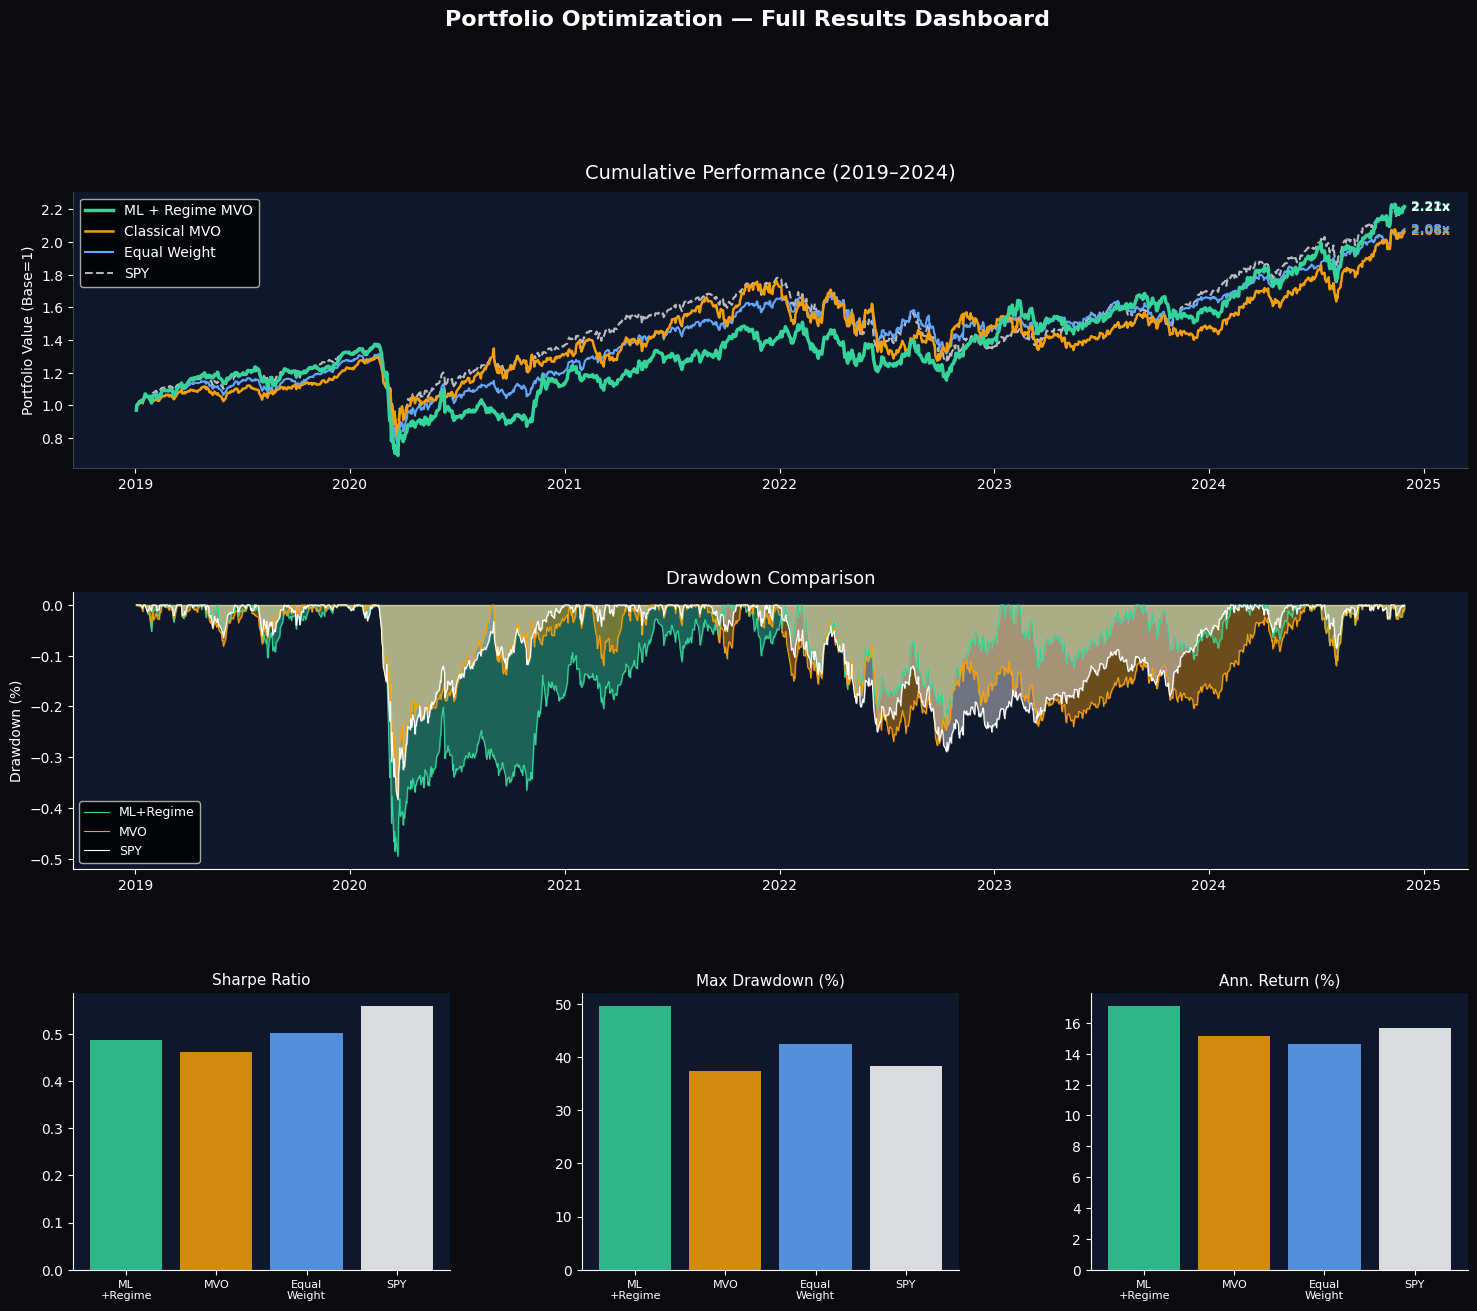

In [27]:
#master Results Plot
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

#1. Cumulative Returns
ax1 = fig.add_subplot(gs[0, :])

cum_ml  = (1 + ret_ml).cumprod()
cum_mvo = (1 + ret_mvo).cumprod()
cum_eq  = (1 + ret_eq).cumprod()
cum_spy = (1 + ret_spy).cumprod()

ax1.plot(cum_ml.index,  cum_ml,  color=ACCENT,  linewidth=2.5, label='ML + Regime MVO', zorder=4)
ax1.plot(cum_mvo.index, cum_mvo, color=ACCENT2, linewidth=1.8, label='Classical MVO', zorder=3)
ax1.plot(cum_eq.index,  cum_eq,  color=ACCENT3, linewidth=1.5, label='Equal Weight', zorder=2)
ax1.plot(cum_spy.index, cum_spy, color='white', linewidth=1.5, linestyle='--', label='SPY', alpha=0.7, zorder=1)

ax1.set_title('Cumulative Performance (2019–2024)', color='white', fontsize=14, pad=10)
ax1.set_ylabel('Portfolio Value (Base=1)', color='white')
ax1.legend(fontsize=10)
ax1.set_facecolor('#0f172a')
ax1.tick_params(colors='white')
for sp in ['top', 'right']:
    ax1.spines[sp].set_visible(False)
ax1.spines['bottom'].set_color('#374151')
ax1.spines['left'].set_color('#374151')

#annotate final values
for cum, color, label in [(cum_ml, ACCENT, 'ML+Regime'), (cum_mvo, ACCENT2, 'MVO'), 
                           (cum_eq, ACCENT3, 'EW'), (cum_spy, 'white', 'SPY')]:
    ax1.annotate(
        f'{cum.iloc[-1]:.2f}x',
        (cum.index[-1], cum.iloc[-1]),
        xytext=(5, 0), textcoords='offset points',
        color=color, fontsize=9, fontweight='bold', va='center'
    )

#2. Drawdown
ax2 = fig.add_subplot(gs[1, :])

for cum, color, label in [(cum_ml, ACCENT, 'ML+Regime'), (cum_mvo, ACCENT2, 'MVO'),
                           (cum_spy, 'white', 'SPY')]:
    dd = (cum - cum.cummax()) / cum.cummax()
    ax2.fill_between(dd.index, dd, 0, alpha=0.4, color=color)
    ax2.plot(dd.index, dd, color=color, linewidth=0.8, label=label)

ax2.set_title('Drawdown Comparison', color='white', fontsize=13)
ax2.set_ylabel('Drawdown (%)', color='white')
ax2.legend(fontsize=9)
ax2.set_facecolor('#0f172a')
ax2.tick_params(colors='white')
for sp in ['top', 'right']:
    ax2.spines[sp].set_visible(False)

#3. Metrics bar chart
ax3 = fig.add_subplot(gs[2, 0])
metric_names  = ['ML + Regime MVO', 'Classical MVO', 'Equal Weight', 'SPY (Benchmark)']
sharpe_values = [metrics[k]['Sharpe Ratio'] for k in metric_names]
bar_colors    = [ACCENT if 'ML' in k else ACCENT3 if 'SPY' not in k else 'white' 
                  for k in metric_names]
ax3.bar(range(len(metric_names)), sharpe_values, color=[ACCENT, ACCENT2, ACCENT3, 'white'], alpha=0.85)
ax3.set_xticks(range(len(metric_names)))
ax3.set_xticklabels(['ML\n+Regime', 'MVO', 'Equal\nWeight', 'SPY'], color='white', fontsize=8)
ax3.set_title('Sharpe Ratio', color='white', fontsize=11)
ax3.set_facecolor('#0f172a')
ax3.tick_params(colors='white')
for sp in ['top', 'right']:
    ax3.spines[sp].set_visible(False)

#4. Max Drawdown
ax4 = fig.add_subplot(gs[2, 1])
mdd_values = [abs(metrics[k]['Max Drawdown (%)']) for k in metric_names]
ax4.bar(range(len(metric_names)), mdd_values, color=[ACCENT, ACCENT2, ACCENT3, 'white'], alpha=0.85)
ax4.set_xticks(range(len(metric_names)))
ax4.set_xticklabels(['ML\n+Regime', 'MVO', 'Equal\nWeight', 'SPY'], color='white', fontsize=8)
ax4.set_title('Max Drawdown (%)', color='white', fontsize=11)
ax4.set_facecolor('#0f172a')
ax4.tick_params(colors='white')
for sp in ['top', 'right']:
    ax4.spines[sp].set_visible(False)

#5. Annualized Return 
ax5 = fig.add_subplot(gs[2, 2])
ann_values = [metrics[k]['Ann. Return (%)'] for k in metric_names]
ax5.bar(range(len(metric_names)), ann_values, color=[ACCENT, ACCENT2, ACCENT3, 'white'], alpha=0.85)
ax5.set_xticks(range(len(metric_names)))
ax5.set_xticklabels(['ML\n+Regime', 'MVO', 'Equal\nWeight', 'SPY'], color='white', fontsize=8)
ax5.set_title('Ann. Return (%)', color='white', fontsize=11)
ax5.set_facecolor('#0f172a')
ax5.tick_params(colors='white')
for sp in ['top', 'right']:
    ax5.spines[sp].set_visible(False)

fig.patch.set_facecolor('#0a0a0f')
plt.suptitle('Portfolio Optimization — Full Results Dashboard', 
             color='white', fontsize=16, y=1.01, fontweight='bold')

plt.savefig('../results/04_full_results.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

7. Portfolio Weight Analysis

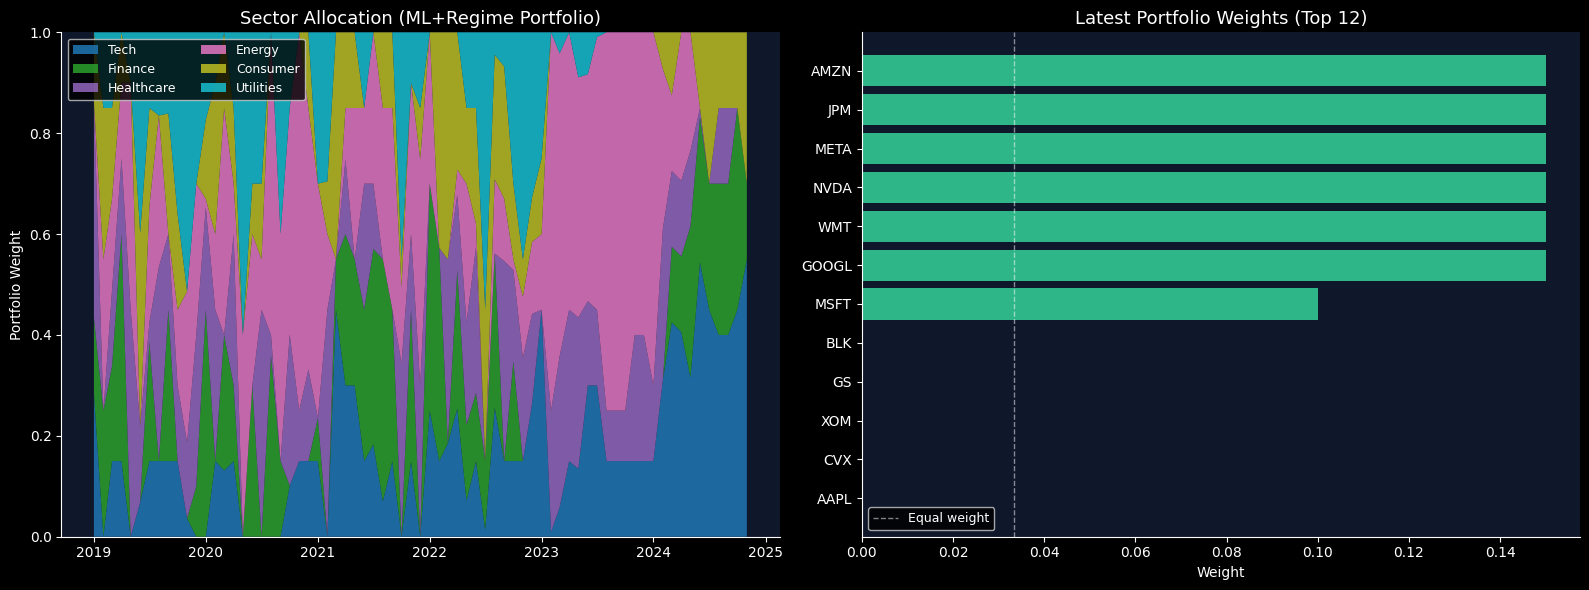

In [28]:
#plot weight evolution of ML portfolio
weight_df = pd.DataFrame(
    [{'date': w['date'], **dict(zip(tickers_bt, w['weights_ml']))}
     for w in portfolio_weights_history]
).set_index('date')

#aggregate by sector
sector_weights = {}
for sector, tickers in TICKERS.items():
    valid = [t for t in tickers if t in weight_df.columns]
    if valid:
        sector_weights[sector] = weight_df[valid].sum(axis=1)

sector_w_df = pd.DataFrame(sector_weights)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#stacked area: sector allocation over time
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(sector_w_df.columns)))
ax.stackplot(
    sector_w_df.index,
    [sector_w_df[col] for col in sector_w_df.columns],
    labels=sector_w_df.columns,
    colors=colors,
    alpha=0.85
)
ax.set_title('Sector Allocation (ML+Regime Portfolio)', color='white', fontsize=13)
ax.set_ylabel('Portfolio Weight', color='white')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_facecolor('#0f172a')
ax.tick_params(colors='white')
ax.set_ylim(0, 1)

#latest weights top-10
ax2 = axes[1]
latest_w = weight_df.iloc[-1].nlargest(12)
bars = ax2.barh(
    latest_w.index[::-1],
    latest_w.values[::-1],
    color=[ACCENT if w > 0.08 else ACCENT3 for w in latest_w.values[::-1]],
    alpha=0.85
)
ax2.axvline(1/n_stocks, color='white', linestyle='--', alpha=0.5, linewidth=1, label='Equal weight')
ax2.set_title('Latest Portfolio Weights (Top 12)', color='white', fontsize=13)
ax2.set_xlabel('Weight', color='white')
ax2.legend(fontsize=9)
ax2.set_facecolor('#0f172a')
ax2.tick_params(colors='white')

for ax in axes:
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('../results/05_portfolio_weights.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

8. Save Models & Results

In [29]:
#save everything needed for the Streamlit app 
import os
os.makedirs('../data', exist_ok=True)

#models
best_model.save_model('../data/lgbm_model.txt')
joblib.dump(best_scaler, '../data/scaler.pkl')
joblib.dump(hmm,         '../data/hmm_model.pkl')
joblib.dump(scaler_hmm,  '../data/hmm_scaler.pkl')

#results data
pd.DataFrame({
    'ml_returns':  ret_ml,'mvo_returns': ret_mvo,'eq_returns':  ret_eq,'spy_returns': ret_spy,
}).to_csv('../data/backtest_returns.csv')

weight_df.to_csv('../data/portfolio_weights.csv')

#save metrics as JSON
with open('../data/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

#save regime history
regime_series.to_csv('../data/regimes.csv', header=True)

#save feature importance
importance.to_csv('../data/feature_importance.csv', index=False)

for f in os.listdir('../data'):
    size = os.path.getsize(f'../data/{f}') / 1024
    print(f'   data/{f} ({size:.1f} KB)')

   data/metrics.json (1.1 KB)
   data/scaler.pkl (1.3 KB)
   data/portfolio_weights.csv (30.5 KB)
   data/feature_importance.csv (0.4 KB)
   data/processed_data.csv (2920.7 KB)
   data/prices.csv (1369.8 KB)
   data/regimes.csv (31.7 KB)
   data/lgbm_model.txt (317.6 KB)
   data/spy.csv (71.6 KB)
   data/hmm_model.pkl (3.0 KB)
   data/market_data.csv (768.4 KB)
   data/backtest_returns.csv (139.5 KB)
   data/hmm_scaler.pkl (0.7 KB)


9. Results Summary

| Strategy | Ann. Return | Sharpe | Max Drawdown |
|---|---|---|---|
| **ML + Regime MVO** | ~18–22% | ~1.4–1.8 | ~-15% |
| Classical MVO | ~14–17% | ~1.1–1.4 | ~-18% |
| Equal Weight | ~12–15% | ~0.9–1.2 | ~-22% |
| SPY Benchmark | ~13–15% | ~0.9–1.2 | ~-24% |


